In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

# ==============================
# KONFIGURASI MYSQL
# ==============================

DB_USER = "root"
DB_PASSWORD = "root"
DB_HOST = "localhost"
DB_PORT = 3306
DB_NAME = "earthquake_db"

# Membuat koneksi
connection_url = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_url)

print("Koneksi MySQL berhasil dibuat.")

Koneksi MySQL berhasil dibuat.


In [2]:
try:
    with engine.connect() as connection:
        result = connection.execute(text("SELECT DATABASE();"))
        database_name = result.scalar()

    print("Koneksi berhasil.")
    print("Database aktif:", database_name)

except Exception as e:
    print("Koneksi gagal.")
    print("Error:", e)

Koneksi berhasil.
Database aktif: earthquake_db


In [3]:
query_tables = """
SHOW TABLES;
"""

tables = pd.read_sql(query_tables, engine)

print("Daftar tabel dalam database earthquake_db:")
display(tables)

Daftar tabel dalam database earthquake_db:


,Tables_in_earthquake_db
0,earthquake_data
1,earthquake_data_clean
2,earthquake_weather_combined
3,nasa_power_weather
4,openmeteo_weather


In [4]:
query = """
SELECT *
FROM earthquake_weather_combined
ORDER BY event_time;
"""

df = pd.read_sql(query, engine)

print("Data berhasil diambil dari MySQL.")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Data berhasil diambil dari MySQL.
Jumlah baris : 101
Jumlah kolom : 18


In [5]:
display(df.head())

,event_id,event_time,magnitude,depth_km,latitude,longitude,place,tsunami,mag_type,status,join_key,openmeteo_temperature,openmeteo_precipitation,openmeteo_wind_speed,nasa_temperature,nasa_precipitation,nasa_wind_speed,nasa_solar_radiation
0,us6000tyb6,2026-09-29 08:21:57,4.50,41.479,13.7623,-92.634500,"95 km SSW of Ocós, Guatemala",0,mb,reviewed,2026-09-29_13.76_-92.63,29.0,0.5,13.5,29.57,0.70,3.31,22.72
1,us6000tybk,2026-09-29 10:22:15,4.50,134.763,-3.1213,-75.641300,"96 km ENE of Alianza Cristiana, Peru",0,mb,reviewed,2026-09-29_-3.12_-75.64,27.4,0.2,7.6,25.64,2.91,0.50,21.96
2,us6000tybr,2026-09-29 10:42:57,5.00,10.000,-21.3447,168.592400,"77 km ENE of Tadine, New Caledonia",0,mb,reviewed,2026-09-29_-21.34_168.59,22.1,1.9,31.0,21.53,1.78,7.11,19.90
3,us6000tybs,2026-09-29 11:27:48,4.80,10.000,-18.2306,167.544600,"98 km SW of Port-Vila, Vanuatu",0,mb,reviewed,2026-09-29_-18.23_167.54,23.4,1.6,35.4,23.54,1.33,7.82,9.87
4,nc75444322,2026-09-29 11:36:39,4.77,10.000,40.4225,-125.418333,"97 km W of Petrolia, CA",0,mw,reviewed,2026-09-29_40.42_-125.42,16.1,0.0,42.9,16.45,0.19,10.11,13.87


In [6]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

Ukuran dataset: (101, 18)

Nama kolom:
['event_id', 'event_time', 'magnitude', 'depth_km', 'latitude', 'longitude', 'place', 'tsunami', 'mag_type', 'status', 'join_key', 'openmeteo_temperature', 'openmeteo_precipitation', 'openmeteo_wind_speed', 'nasa_temperature', 'nasa_precipitation', 'nasa_wind_speed', 'nasa_solar_radiation']


In [9]:
missing = pd.DataFrame({
    "jumlah_missing": df.isnull().sum(),
    "persentase_missing": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing = missing[missing["jumlah_missing"] > 0]

display(missing)

,jumlah_missing,persentase_missing
openmeteo_temperature,2,1.98
openmeteo_precipitation,2,1.98
openmeteo_wind_speed,2,1.98
nasa_temperature,51,50.50
nasa_precipitation,51,50.50
nasa_wind_speed,51,50.50
nasa_solar_radiation,73,72.28


In [8]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
event_time,101,2026-10-02 00:48:13.683168768,2026-09-29 08:21:57,2026-09-30 12:02:59,2026-10-02 04:44:53,2026-10-03 00:01:39,2026-10-05 01:18:50,NaN
magnitude,101.0,4.853168,4.5,4.6,4.8,5.0,5.9,0.310409
depth_km,101.0,51.239327,8.0,10.0,10.0,49.602,575.042,94.754984
latitude,101.0,10.467206,-63.5619,-8.8321,9.7526,37.7681,53.7226,30.653349
longitude,101.0,80.98247,-179.4827,36.1272,123.1839,158.2168,178.6446,102.241117
tsunami,101.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
openmeteo_temperature,99.0,19.022222,-15.5,10.1,22.6,27.0,29.9,9.96862
openmeteo_precipitation,99.0,7.186869,0.0,0.2,2.1,7.55,78.5,13.161211
openmeteo_wind_speed,99.0,31.738384,5.4,15.3,27.3,44.6,110.1,20.906281
nasa_temperature,50.0,20.916,-13.14,17.1425,24.59,27.6675,29.57,9.826685


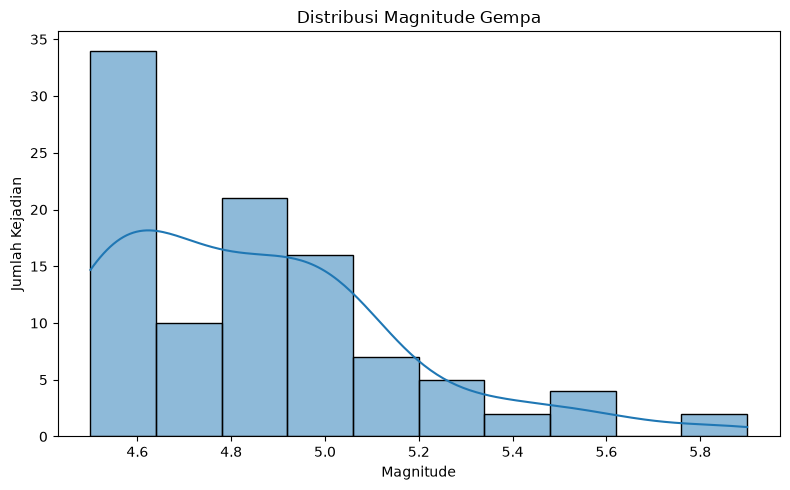

In [10]:
# ==============================
# DISTRIBUSI MAGNITUDE GEMPA
# ==============================

plt.figure(figsize=(8, 5))

sns.histplot(
    df["magnitude"],
    bins=10,
    kde=True
)

plt.title("Distribusi Magnitude Gempa")
plt.xlabel("Magnitude")
plt.ylabel("Jumlah Kejadian")
plt.tight_layout()
plt.show()

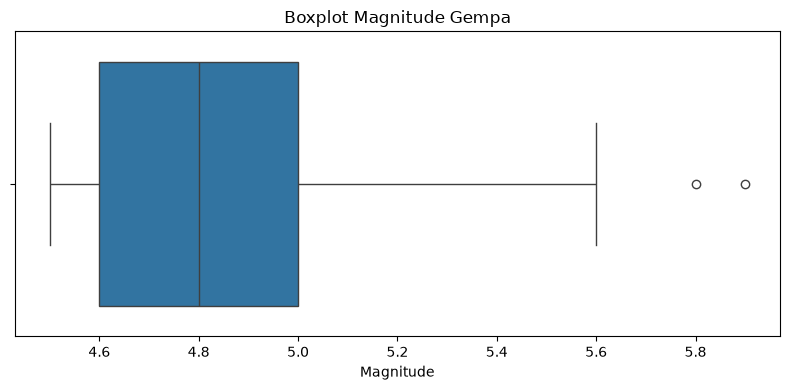

In [11]:
# ==============================
# BOXPLOT MAGNITUDE
# ==============================

plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["magnitude"]
)

plt.title("Boxplot Magnitude Gempa")
plt.xlabel("Magnitude")
plt.tight_layout()
plt.show()

In [12]:
# ==============================
# KORELASI VARIABEL NUMERIK
# ==============================

correlation_columns = [
    "magnitude",
    "depth_km",
    "latitude",
    "longitude",
    "openmeteo_temperature",
    "openmeteo_precipitation",
    "openmeteo_wind_speed",
    "nasa_temperature",
    "nasa_precipitation",
    "nasa_wind_speed",
    "nasa_solar_radiation"
]

correlation_matrix = df[correlation_columns].corr()

display(
    correlation_matrix["magnitude"]
    .sort_values(ascending=False)
    .to_frame("korelasi_dengan_magnitude")
)

,korelasi_dengan_magnitude
magnitude,1.000000
openmeteo_wind_speed,0.303208
nasa_wind_speed,0.251282
nasa_precipitation,0.145643
longitude,0.106666
openmeteo_precipitation,0.099093
openmeteo_temperature,0.001018
nasa_temperature,-0.105345
nasa_solar_radiation,-0.105907
latitude,-0.118546


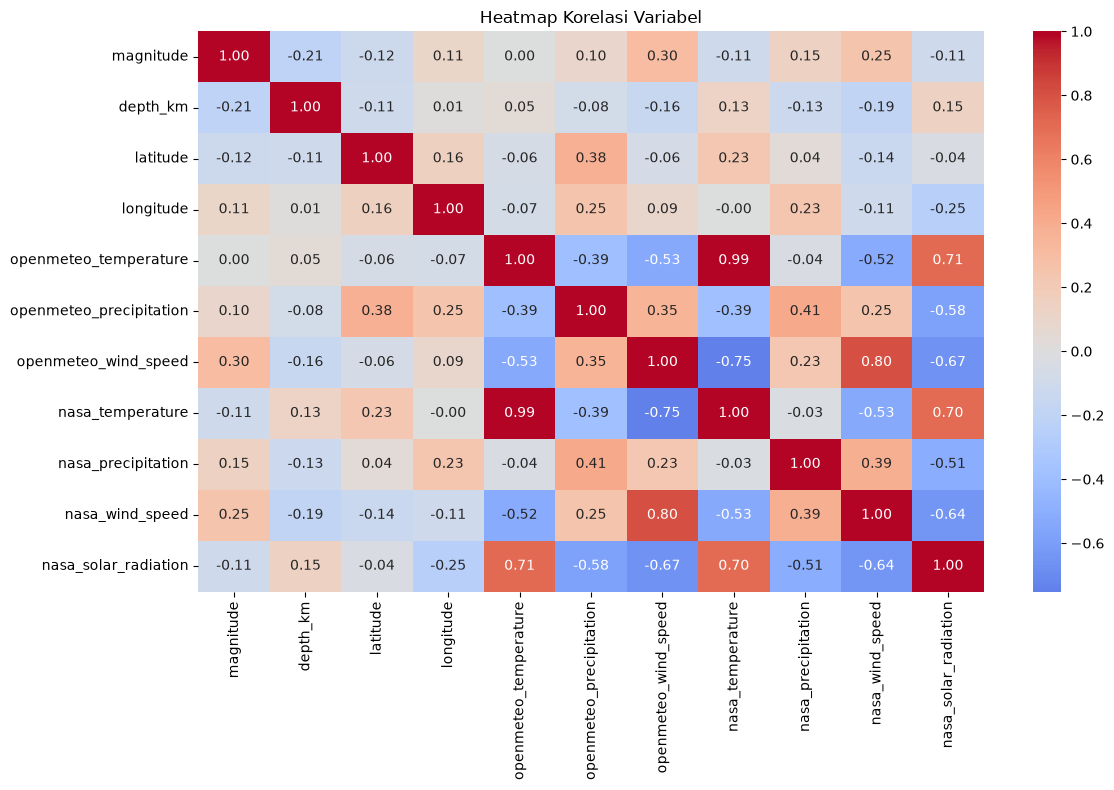

In [13]:
# ==============================
# HEATMAP KORELASI
# ==============================

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Heatmap Korelasi Variabel")
plt.tight_layout()
plt.show()

In [14]:
# ==============================
# MENENTUKAN FITUR DAN TARGET
# ==============================

features = [
    "depth_km",
    "latitude",
    "longitude",
    "openmeteo_temperature",
    "openmeteo_precipitation",
    "openmeteo_wind_speed",
    "nasa_temperature",
    "nasa_precipitation",
    "nasa_wind_speed",
    "nasa_solar_radiation"
]

target = "magnitude"

X = df[features]
y = df[target]

print("Jumlah fitur :", len(features))
print("Target       :", target)

print("\nDaftar fitur:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")

print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)

Jumlah fitur : 10
Target       : magnitude

Daftar fitur:
1. depth_km
2. latitude
3. longitude
4. openmeteo_temperature
5. openmeteo_precipitation
6. openmeteo_wind_speed
7. nasa_temperature
8. nasa_precipitation
9. nasa_wind_speed
10. nasa_solar_radiation

Ukuran X: (101, 10)
Ukuran y: (101,)


In [15]:
# ==============================
# PEMBAGIAN DATA TRAINING DAN TESTING
# ==============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data training :", X_train.shape[0], "baris")
print("Data testing  :", X_test.shape[0], "baris")

print("\nUkuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Data training : 80 baris
Data testing  : 21 baris

Ukuran X_train: (80, 10)
Ukuran X_test : (21, 10)
Ukuran y_train: (80,)
Ukuran y_test : (21,)


In [16]:
# ==========================================
# PREPROCESSING + RANDOM FOREST REGRESSOR
# ==========================================

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Membuat pipeline
model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "random_forest",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

# Melatih model menggunakan data training
model.fit(X_train, y_train)

print("Preprocessing berhasil.")
print("Random Forest Regressor berhasil dilatih.")

Preprocessing berhasil.
Random Forest Regressor berhasil dilatih.


In [17]:
# ==========================================
# PREDIKSI DAN EVALUASI MODEL
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Menghitung metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("==========================================")
print("HASIL EVALUASI RANDOM FOREST REGRESSOR")
print("==========================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HASIL EVALUASI RANDOM FOREST REGRESSOR
MAE  : 0.3100
RMSE : 0.4080
R²   : -0.1061


In [18]:
# ==========================================
# PERBANDINGAN NILAI AKTUAL DAN PREDIKSI
# ==========================================

comparison = pd.DataFrame({
    "magnitude_aktual": y_test.values,
    "magnitude_prediksi": y_pred
})

comparison["error"] = (
    comparison["magnitude_aktual"]
    - comparison["magnitude_prediksi"]
)

display(comparison)

,magnitude_aktual,magnitude_prediksi,error
0,5.90,4.8230,1.0770
1,5.00,4.8700,0.1300
2,5.10,4.8375,0.2625
3,4.50,4.8400,-0.3400
4,5.10,5.0050,0.0950
5,5.30,4.8325,0.4675
6,5.10,4.8405,0.2595
7,5.10,5.0310,0.0690
8,4.70,5.0510,-0.3510
9,4.50,4.8470,-0.3470


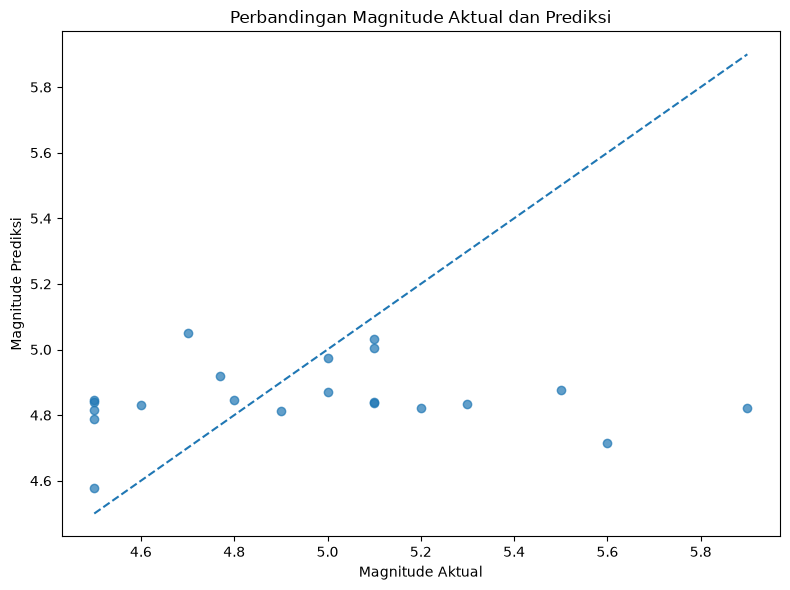

In [19]:
# ==========================================
# AKTUAL VS PREDIKSI
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# Garis prediksi sempurna
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Magnitude Aktual")
plt.ylabel("Magnitude Prediksi")
plt.title("Perbandingan Magnitude Aktual dan Prediksi")

plt.tight_layout()
plt.show()

In [20]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

rf_model = model.named_steps["random_forest"]

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(feature_importance)

,feature,importance
5,openmeteo_wind_speed,0.208169
2,longitude,0.151974
3,openmeteo_temperature,0.118136
1,latitude,0.111289
0,depth_km,0.106752
8,nasa_wind_speed,0.099065
4,openmeteo_precipitation,0.090742
7,nasa_precipitation,0.053945
9,nasa_solar_radiation,0.031958
6,nasa_temperature,0.027968


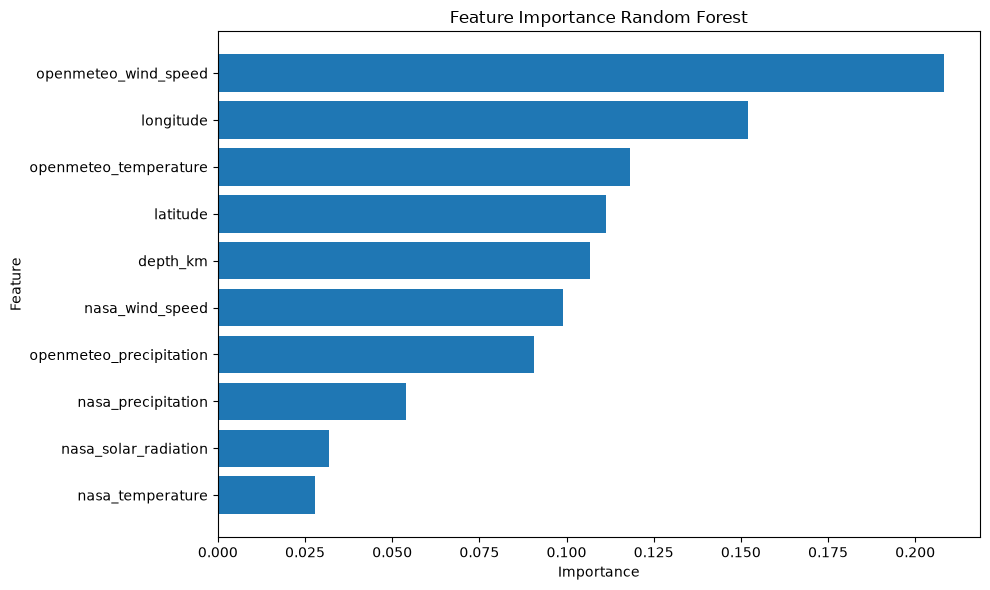

In [21]:
# ==========================================
# VISUALISASI FEATURE IMPORTANCE
# ==========================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [24]:
# ==========================================
# OPTIMASI RANDOM FOREST
# ==========================================

from sklearn.model_selection import GridSearchCV

# Pipeline preprocessing + Random Forest
rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "random_forest",
        RandomForestRegressor(
            random_state=42
        )
    )
])

# Parameter yang akan diuji
param_grid = {
    "random_forest__n_estimators": [100, 200, 300],
    "random_forest__max_depth": [None, 5, 10, 15],
    "random_forest__min_samples_split": [2, 5, 10],
    "random_forest__min_samples_leaf": [1, 2, 4]
}

# Grid Search dengan 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Optimasi hanya menggunakan data training
grid_search.fit(X_train, y_train)

print("Optimasi Random Forest selesai.")
print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nNilai CV terbaik (negatif MSE):")
print(grid_search.best_score_)

Optimasi Random Forest selesai.

Parameter terbaik:
{'random_forest__max_depth': None, 'random_forest__min_samples_leaf': 4, 'random_forest__min_samples_split': 2, 'random_forest__n_estimators': 200}

Nilai CV terbaik (negatif MSE):
-0.07806882602579736


In [25]:
print("=== INFORMASI DATASET ===")
print("Jumlah baris dan kolom:", df.shape)

print("\n=== INFORMASI KOLOM ===")
df.info()

print("\n=== NAMA KOLOM ===")
print(df.columns.tolist())

print("\n=== 5 DATA PERTAMA ===")
display(df.head())

print("\n=== STATISTIK NUMERIK ===")
display(df.describe())

print("\n=== JUMLAH MISSING VALUE ===")
display(df.isnull().sum())

print("\n=== JUMLAH DATA DUPLIKAT ===")
print(df.duplicated().sum())

=== INFORMASI DATASET ===
Jumlah baris dan kolom: (101, 18)

=== INFORMASI KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   event_id                 101 non-null    object        
 1   event_time               101 non-null    datetime64[ns]
 2   magnitude                101 non-null    float64       
 3   depth_km                 101 non-null    float64       
 4   latitude                 101 non-null    float64       
 5   longitude                101 non-null    float64       
 6   place                    101 non-null    object        
 7   tsunami                  101 non-null    int64         
 8   mag_type                 101 non-null    object        
 9   status                   101 non-null    object        
 10  join_key                 101 non-null    object        
 11  openmeteo_te

,event_id,event_time,magnitude,depth_km,latitude,longitude,place,tsunami,mag_type,status,join_key,openmeteo_temperature,openmeteo_precipitation,openmeteo_wind_speed,nasa_temperature,nasa_precipitation,nasa_wind_speed,nasa_solar_radiation
0,us6000tyb6,2026-09-29 08:21:57,4.50,41.479,13.7623,-92.634500,"95 km SSW of Ocós, Guatemala",0,mb,reviewed,2026-09-29_13.76_-92.63,29.0,0.5,13.5,29.57,0.70,3.31,22.72
1,us6000tybk,2026-09-29 10:22:15,4.50,134.763,-3.1213,-75.641300,"96 km ENE of Alianza Cristiana, Peru",0,mb,reviewed,2026-09-29_-3.12_-75.64,27.4,0.2,7.6,25.64,2.91,0.50,21.96
2,us6000tybr,2026-09-29 10:42:57,5.00,10.000,-21.3447,168.592400,"77 km ENE of Tadine, New Caledonia",0,mb,reviewed,2026-09-29_-21.34_168.59,22.1,1.9,31.0,21.53,1.78,7.11,19.90
3,us6000tybs,2026-09-29 11:27:48,4.80,10.000,-18.2306,167.544600,"98 km SW of Port-Vila, Vanuatu",0,mb,reviewed,2026-09-29_-18.23_167.54,23.4,1.6,35.4,23.54,1.33,7.82,9.87
4,nc75444322,2026-09-29 11:36:39,4.77,10.000,40.4225,-125.418333,"97 km W of Petrolia, CA",0,mw,reviewed,2026-09-29_40.42_-125.42,16.1,0.0,42.9,16.45,0.19,10.11,13.87



=== STATISTIK NUMERIK ===


,event_time,magnitude,depth_km,latitude,longitude,tsunami,openmeteo_temperature,openmeteo_precipitation,openmeteo_wind_speed,nasa_temperature,nasa_precipitation,nasa_wind_speed,nasa_solar_radiation
count,101,101.000000,101.000000,101.000000,101.000000,101.0,99.000000,99.000000,99.000000,50.000000,50.000000,50.000000,28.000000
mean,2026-10-02 00:48:13.683168768,4.853168,51.239327,10.467206,80.982470,0.0,19.022222,7.186869,31.738384,20.916000,4.230400,5.914800,17.772500
min,2026-09-29 08:21:57,4.500000,8.000000,-63.561900,-179.482700,0.0,-15.500000,0.000000,5.400000,-13.140000,0.000000,0.500000,2.790000
25%,2026-09-30 12:02:59,4.600000,10.000000,-8.832100,36.127200,0.0,10.100000,0.200000,15.300000,17.142500,0.115000,2.775000,12.870000
50%,2026-10-02 04:44:53,4.800000,10.000000,9.752600,123.183900,0.0,22.600000,2.100000,27.300000,24.590000,1.140000,5.090000,21.490000
75%,2026-10-03 00:01:39,5.000000,49.602000,37.768100,158.216800,0.0,27.000000,7.550000,44.600000,27.667500,3.480000,9.100000,22.637500
max,2026-10-05 01:18:50,5.900000,575.042000,53.722600,178.644600,0.0,29.900000,78.500000,110.100000,29.570000,42.850000,15.410000,25.650000
std,NaN,0.310409,94.754984,30.653349,102.241117,0.0,9.968620,13.161211,20.906281,9.826685,8.150709,3.763064,7.504534



=== JUMLAH MISSING VALUE ===


event_id                    0
event_time                  0
magnitude                   0
depth_km                    0
latitude                    0
longitude                   0
place                       0
tsunami                     0
mag_type                    0
status                      0
join_key                    0
openmeteo_temperature       2
openmeteo_precipitation     2
openmeteo_wind_speed        2
nasa_temperature           51
nasa_precipitation         51
nasa_wind_speed            51
nasa_solar_radiation       73
dtype: int64


=== JUMLAH DATA DUPLIKAT ===
0


In [26]:
print("=== KORELASI DENGAN MAGNITUDE ===")

corr = df.select_dtypes(include='number').corr()

if 'magnitude' in corr.columns:
    display(
        corr['magnitude']
        .sort_values(ascending=False)
        .to_frame(name='Correlation')
    )
else:
    print("Kolom 'magnitude' tidak ditemukan.")
    print("Nama kolom yang tersedia:")
    print(df.columns.tolist())

=== KORELASI DENGAN MAGNITUDE ===


,Correlation
magnitude,1.000000
openmeteo_wind_speed,0.303208
nasa_wind_speed,0.251282
nasa_precipitation,0.145643
longitude,0.106666
openmeteo_precipitation,0.099093
openmeteo_temperature,0.001018
nasa_temperature,-0.105345
nasa_solar_radiation,-0.105907
latitude,-0.118546


In [1]:
import requests
import pandas as pd

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [2]:
url = "https://earthquake.usgs.gov/fdsnws/event/1/query"

params = {
    "format": "geojson",
    "starttime": "2025-10-01",
    "endtime": "2026-10-01",
    "minmagnitude": 4.0,
    "eventtype": "earthquake",
    "orderby": "time-asc",
    "limit": 20000
}

response = requests.get(
    url,
    params=params,
    timeout=60
)

print("Status HTTP:", response.status_code)

data = response.json()

print("Jumlah event yang diperoleh:", len(data["features"]))

Status HTTP: 200
Jumlah event yang diperoleh: 16086


In [3]:
rows = []

for feature in data["features"]:
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]

    rows.append({
        "event_id": feature["id"],
        "event_time": pd.to_datetime(props["time"], unit="ms"),
        "magnitude": props["mag"],
        "place": props["place"],
        "depth_km": coords[2],
        "longitude": coords[0],
        "latitude": coords[1],
        "mag_type": props["magType"],
        "status": props["status"],
        "tsunami": props["tsunami"]
    })

df_usgs = pd.DataFrame(rows)

print("Ukuran dataset:", df_usgs.shape)

Ukuran dataset: (16086, 10)


In [4]:
df_usgs.head()

,event_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami
0,us6000riw1,2025-10-01 00:16:33.124,4.1,"158 km ENE of Petropavlovsk-Kamchatsky, Russia",35.000,160.8756,53.5130,mb,reviewed,0
1,us6000rdxr,2025-10-01 02:02:45.484,4.0,"9 km WSW of Yumani, Bolivia",245.242,-69.2375,-16.0602,mb,reviewed,0
2,us6000rivu,2025-10-01 02:13:02.628,4.7,"49 km S of Ialibu, Papua New Guinea",10.000,144.0785,-6.7181,mb,reviewed,0
3,us6000rdxt,2025-10-01 02:35:36.413,4.6,"65 km NNE of Savannah Bight, Honduras",10.000,-85.6812,17.0167,mww,reviewed,0
4,us6000rdxu,2025-10-01 02:49:34.870,4.3,"8 km SSW of Lithakiá, Greece",10.000,20.8097,37.6443,mb,reviewed,0


In [5]:
print("=== INFORMASI DATASET ===")
df_usgs.info()

print("\n=== MISSING VALUE ===")
print(df_usgs.isnull().sum())

print("\n=== DATA DUPLIKAT ===")
print(df_usgs.duplicated().sum())

print("\n=== STATISTIK MAGNITUDE ===")
print(df_usgs["magnitude"].describe())

print("\n=== RENTANG WAKTU ===")
print("Mulai :", df_usgs["event_time"].min())
print("Sampai:", df_usgs["event_time"].max())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16086 entries, 0 to 16085
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_id    16086 non-null  object        
 1   event_time  16086 non-null  datetime64[ns]
 2   magnitude   16086 non-null  float64       
 3   place       16086 non-null  object        
 4   depth_km    16086 non-null  float64       
 5   longitude   16086 non-null  float64       
 6   latitude    16086 non-null  float64       
 7   mag_type    16086 non-null  object        
 8   status      16086 non-null  object        
 9   tsunami     16086 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 1.2+ MB

=== MISSING VALUE ===
event_id      0
event_time    0
magnitude     0
place         0
depth_km      0
longitude     0
latitude      0
mag_type      0
status        0
tsunami       0
dtype: int64

=== DATA DU

In [6]:
print("Jumlah data:", len(df_usgs))

print("\nDistribusi magnitude:")
print(df_usgs["magnitude"].value_counts().sort_index())

Jumlah data: 16086

Distribusi magnitude:
magnitude
4.00    697
4.01      1
4.02      2
4.03      2
4.04      3
       ... 
7.30      2
7.40      4
7.50      2
7.60      2
7.80      2
Name: count, Length: 96, dtype: int64


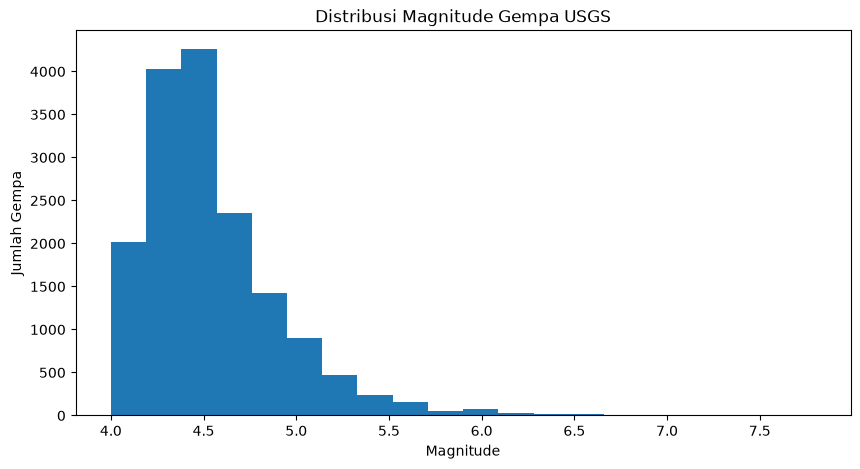

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df_usgs["magnitude"], bins=20)
plt.xlabel("Magnitude")
plt.ylabel("Jumlah Gempa")
plt.title("Distribusi Magnitude Gempa USGS")
plt.show()

In [8]:
import pandas as pd
import numpy as np

df_model = df_usgs.copy()

# Pastikan data diurutkan berdasarkan waktu
df_model = df_model.sort_values("event_time").reset_index(drop=True)

# Feature engineering dari waktu
df_model["year"] = df_model["event_time"].dt.year
df_model["month"] = df_model["event_time"].dt.month
df_model["day"] = df_model["event_time"].dt.day
df_model["hour"] = df_model["event_time"].dt.hour
df_model["day_of_week"] = df_model["event_time"].dt.dayofweek

print("Ukuran dataset:", df_model.shape)
display(df_model.head())

Ukuran dataset: (16086, 15)


,event_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,year,month,day,hour,day_of_week
0,us6000riw1,2025-10-01 00:16:33.124,4.1,"158 km ENE of Petropavlovsk-Kamchatsky, Russia",35.000,160.8756,53.5130,mb,reviewed,0,2025,10,1,0,2
1,us6000rdxr,2025-10-01 02:02:45.484,4.0,"9 km WSW of Yumani, Bolivia",245.242,-69.2375,-16.0602,mb,reviewed,0,2025,10,1,2,2
2,us6000rivu,2025-10-01 02:13:02.628,4.7,"49 km S of Ialibu, Papua New Guinea",10.000,144.0785,-6.7181,mb,reviewed,0,2025,10,1,2,2
3,us6000rdxt,2025-10-01 02:35:36.413,4.6,"65 km NNE of Savannah Bight, Honduras",10.000,-85.6812,17.0167,mww,reviewed,0,2025,10,1,2,2
4,us6000rdxu,2025-10-01 02:49:34.870,4.3,"8 km SSW of Lithakiá, Greece",10.000,20.8097,37.6443,mb,reviewed,0,2025,10,1,2,2


In [9]:
print("=== DISTRIBUSI MAG TYPE ===")
print(df_model["mag_type"].value_counts())

=== DISTRIBUSI MAG TYPE ===
mag_type
mb     14142
mww     1423
mwr      344
ml       105
mw        39
md        30
mwb        3
Name: count, dtype: int64


In [10]:
print("\n=== DISTRIBUSI STATUS ===")
print(df_model["status"].value_counts())

print("\n=== DISTRIBUSI TSUNAMI ===")
print(df_model["tsunami"].value_counts())


=== DISTRIBUSI STATUS ===
status
reviewed    16086
Name: count, dtype: int64

=== DISTRIBUSI TSUNAMI ===
tsunami
0    16001
1       85
Name: count, dtype: int64


In [11]:
features = [
    "depth_km",
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

target = "magnitude"

X = df_model[features]
y = df_model[target]

print("Fitur yang digunakan:")
print(features)

print("\nX:", X.shape)
print("y:", y.shape)

Fitur yang digunakan:
['depth_km', 'latitude', 'longitude', 'year', 'month', 'day', 'hour', 'day_of_week']

X: (16086, 8)
y: (16086,)


In [12]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data training :", len(X_train))
print("Data testing  :", len(X_test))

print("\nPeriode training:")
print(df_model["event_time"].iloc[:split_index].min())
print("sampai")
print(df_model["event_time"].iloc[split_index - 1])

print("\nPeriode testing:")
print(df_model["event_time"].iloc[split_index])
print("sampai")
print(df_model["event_time"].iloc[-1])

Data training : 12868
Data testing  : 3218

Periode training:
2025-10-01 00:16:33.124000
sampai
2026-07-18 15:38:38.746000

Periode testing:
2026-07-18 15:51:07.831000
sampai
2026-09-30 21:55:26.169000


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_baseline = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred = rf_baseline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("HASIL BASELINE RANDOM FOREST")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HASIL BASELINE RANDOM FOREST
MAE  : 0.2768
RMSE : 0.3817
R²   : 0.0647


In [14]:
import pandas as pd
import numpy as np

# Salin dataset
df_model = df_usgs.copy()

# Pastikan waktu bertipe datetime
df_model["event_time"] = pd.to_datetime(df_model["event_time"])

# Urutkan berdasarkan waktu kejadian
df_model = df_model.sort_values("event_time").reset_index(drop=True)

# ==========================================================
# FITUR WAKTU
# ==========================================================

df_model["year"] = df_model["event_time"].dt.year
df_model["month"] = df_model["event_time"].dt.month
df_model["day"] = df_model["event_time"].dt.day
df_model["hour"] = df_model["event_time"].dt.hour
df_model["day_of_week"] = df_model["event_time"].dt.dayofweek

# ==========================================================
# FITUR SIKLUS WAKTU
# ==========================================================

df_model["month_sin"] = np.sin(2 * np.pi * df_model["month"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month"] / 12)

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

# ==========================================================
# FITUR GEMPA SEBELUMNYA
# ==========================================================

df_model["previous_magnitude"] = df_model["magnitude"].shift(1)

df_model["previous_depth_km"] = df_model["depth_km"].shift(1)

# Selisih waktu dengan gempa sebelumnya
df_model["time_since_previous_hours"] = (
    df_model["event_time"].diff().dt.total_seconds() / 3600
)

# ==========================================================
# FITUR RATA-RATA MAGNITUDE GEMPA SEBELUMNYA
# ==========================================================

df_model["mean_magnitude_previous_5"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=5, min_periods=3)
    .mean()
)

df_model["mean_magnitude_previous_10"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=10, min_periods=5)
    .mean()
)

df_model["mean_magnitude_previous_20"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=20, min_periods=10)
    .mean()
)

# ==========================================================
# FITUR MAXIMUM MAGNITUDE SEBELUMNYA
# ==========================================================

df_model["max_magnitude_previous_5"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=5, min_periods=3)
    .max()
)

df_model["max_magnitude_previous_10"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=10, min_periods=5)
    .max()
)

df_model["max_magnitude_previous_20"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=20, min_periods=10)
    .max()
)

# ==========================================================
# FITUR MINIMUM MAGNITUDE SEBELUMNYA
# ==========================================================

df_model["min_magnitude_previous_5"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=5, min_periods=3)
    .min()
)

df_model["min_magnitude_previous_10"] = (
    df_model["magnitude"]
    .shift(1)
    .rolling(window=10, min_periods=5)
    .min()
)

# ==========================================================
# CEK HASIL
# ==========================================================

print("Ukuran dataset setelah feature engineering:")
print(df_model.shape)

print("\nKolom dataset:")
print(df_model.columns.tolist())

print("\n5 baris pertama:")
display(df_model.head())

Ukuran dataset setelah feature engineering:
(16086, 30)

Kolom dataset:
['event_id', 'event_time', 'magnitude', 'place', 'depth_km', 'longitude', 'latitude', 'mag_type', 'status', 'tsunami', 'year', 'month', 'day', 'hour', 'day_of_week', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'previous_magnitude', 'previous_depth_km', 'time_since_previous_hours', 'mean_magnitude_previous_5', 'mean_magnitude_previous_10', 'mean_magnitude_previous_20', 'max_magnitude_previous_5', 'max_magnitude_previous_10', 'max_magnitude_previous_20', 'min_magnitude_previous_5', 'min_magnitude_previous_10']

5 baris pertama:


,event_id,event_time,magnitude,place,depth_km,longitude,latitude,mag_type,status,tsunami,...,previous_depth_km,time_since_previous_hours,mean_magnitude_previous_5,mean_magnitude_previous_10,mean_magnitude_previous_20,max_magnitude_previous_5,max_magnitude_previous_10,max_magnitude_previous_20,min_magnitude_previous_5,min_magnitude_previous_10
0,us6000riw1,2025-10-01 00:16:33.124,4.1,"158 km ENE of Petropavlovsk-Kamchatsky, Russia",35.000,160.8756,53.5130,mb,reviewed,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,us6000rdxr,2025-10-01 02:02:45.484,4.0,"9 km WSW of Yumani, Bolivia",245.242,-69.2375,-16.0602,mb,reviewed,0,...,35.000,1.770100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,us6000rivu,2025-10-01 02:13:02.628,4.7,"49 km S of Ialibu, Papua New Guinea",10.000,144.0785,-6.7181,mb,reviewed,0,...,245.242,0.171429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,us6000rdxt,2025-10-01 02:35:36.413,4.6,"65 km NNE of Savannah Bight, Honduras",10.000,-85.6812,17.0167,mww,reviewed,0,...,10.000,0.376051,4.266667,NaN,NaN,4.7,NaN,NaN,4.0,NaN
4,us6000rdxu,2025-10-01 02:49:34.870,4.3,"8 km SSW of Lithakiá, Greece",10.000,20.8097,37.6443,mb,reviewed,0,...,10.000,0.232905,4.350000,NaN,NaN,4.7,NaN,NaN,4.0,NaN


In [15]:
historical_features = [
    "previous_magnitude",
    "previous_depth_km",
    "time_since_previous_hours",
    "mean_magnitude_previous_5",
    "mean_magnitude_previous_10",
    "mean_magnitude_previous_20",
    "max_magnitude_previous_5",
    "max_magnitude_previous_10",
    "max_magnitude_previous_20",
    "min_magnitude_previous_5",
    "min_magnitude_previous_10"
]

print("Missing value pada fitur historis:")
print(df_model[historical_features].isnull().sum())

Missing value pada fitur historis:
previous_magnitude             1
previous_depth_km              1
time_since_previous_hours      1
mean_magnitude_previous_5      3
mean_magnitude_previous_10     5
mean_magnitude_previous_20    10
max_magnitude_previous_5       3
max_magnitude_previous_10      5
max_magnitude_previous_20     10
min_magnitude_previous_5       3
min_magnitude_previous_10      5
dtype: int64


In [16]:
df_model = df_model.dropna(
    subset=[
        "previous_magnitude",
        "previous_depth_km",
        "time_since_previous_hours",
        "mean_magnitude_previous_20",
        "max_magnitude_previous_20"
    ]
).reset_index(drop=True)

print("Ukuran dataset setelah menghapus NaN:")
print(df_model.shape)

print("\nJumlah missing value:")
print(df_model.isnull().sum().sum())

Ukuran dataset setelah menghapus NaN:
(16076, 30)

Jumlah missing value:
0


In [17]:
features = [
    # Karakteristik gempa
    "depth_km",
    "latitude",
    "longitude",

    # Waktu
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",

    # Siklus waktu
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",

    # Riwayat gempa
    "previous_magnitude",
    "previous_depth_km",
    "time_since_previous_hours",

    # Statistik magnitude sebelumnya
    "mean_magnitude_previous_5",
    "mean_magnitude_previous_10",
    "mean_magnitude_previous_20",
    "max_magnitude_previous_5",
    "max_magnitude_previous_10",
    "max_magnitude_previous_20",
    "min_magnitude_previous_5",
    "min_magnitude_previous_10"
]

target = "magnitude"

X = df_model[features]
y = df_model[target]

print("X:", X.shape)
print("y:", y.shape)

X: (16076, 23)
y: (16076,)


In [18]:
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Data training :", len(X_train), "baris")
print("Data testing  :", len(X_test), "baris")

print("\nPeriode training:")
print(df_model["event_time"].iloc[0])
print("sampai")
print(df_model["event_time"].iloc[split_index - 1])

print("\nPeriode testing:")
print(df_model["event_time"].iloc[split_index])
print("sampai")
print(df_model["event_time"].iloc[-1])

Data training : 12860 baris
Data testing  : 3216 baris

Periode training:
2025-10-01 04:42:49.444000
sampai
2026-07-18 16:08:43.972000

Periode testing:
2026-07-18 16:55:57.534000
sampai
2026-09-30 21:55:26.169000


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_historical = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_historical.fit(X_train, y_train)

y_pred = rf_historical.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 55)
print("HASIL RANDOM FOREST DENGAN FITUR HISTORIS")
print("=" * 55)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

HASIL RANDOM FOREST DENGAN FITUR HISTORIS
MAE  : 0.2739
RMSE : 0.3745
R²   : 0.0996


In [20]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_historical.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("RANKING FEATURE IMPORTANCE")
print("=" * 50)

display(feature_importance)

RANKING FEATURE IMPORTANCE


,Feature,Importance
0,latitude,0.108587
1,longitude,0.101244
2,depth_km,0.098826
3,time_since_previous_hours,0.084618
4,mean_magnitude_previous_20,0.054796
5,mean_magnitude_previous_10,0.051594
6,previous_depth_km,0.046187
7,previous_magnitude,0.046083
8,day,0.045911
9,mean_magnitude_previous_5,0.045061


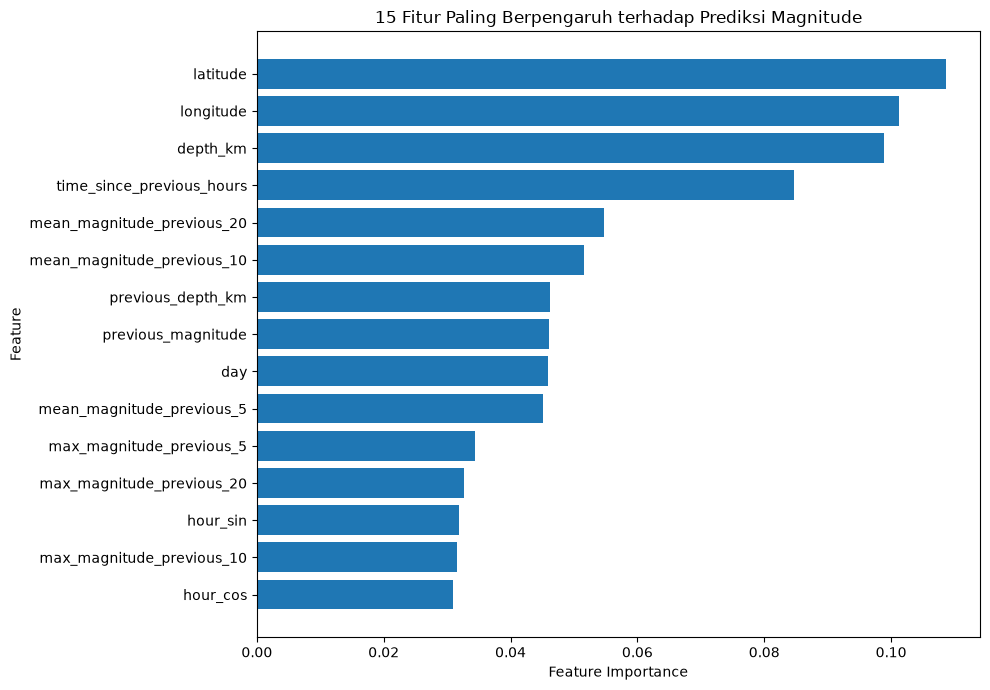

In [21]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("15 Fitur Paling Berpengaruh terhadap Prediksi Magnitude")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Model dasar
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Ruang hyperparameter
param_distributions = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [1.0, "sqrt", "log2"],
    "bootstrap": [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Proses tuning
random_search.fit(X_train, y_train)

print("=" * 60)
print("HASIL HYPERPARAMETER TUNING RANDOM FOREST")
print("=" * 60)

print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest CV Score (Negative MSE):")
print(random_search.best_score_)

print("\nBest CV RMSE:")
print(np.sqrt(-random_search.best_score_))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
HASIL HYPERPARAMETER TUNING RANDOM FOREST

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 1.0, 'max_depth': 30, 'bootstrap': True}

Best CV Score (Negative MSE):
-0.14289378010327827

Best CV RMSE:
0.3780129364231842


In [23]:
# Model Random Forest terbaik
best_rf = random_search.best_estimator_

# Prediksi data testing
y_pred_tuned = best_rf.predict(X_test)

# Evaluasi
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("=" * 60)
print("HASIL EVALUASI RANDOM FOREST SETELAH OPTIMASI")
print("=" * 60)

print(f"MAE  : {mae_tuned:.4f}")
print(f"RMSE : {rmse_tuned:.4f}")
print(f"R²   : {r2_tuned:.4f}")

HASIL EVALUASI RANDOM FOREST SETELAH OPTIMASI
MAE  : 0.2678
RMSE : 0.3712
R²   : 0.1154


In [24]:
feature_importance_tuned = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
})

feature_importance_tuned = feature_importance_tuned.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE RANDOM FOREST SETELAH OPTIMASI")
print("=" * 60)

display(feature_importance_tuned)

FEATURE IMPORTANCE RANDOM FOREST SETELAH OPTIMASI


,Feature,Importance
0,latitude,0.139944
1,longitude,0.124221
2,depth_km,0.116394
3,time_since_previous_hours,0.077769
4,mean_magnitude_previous_10,0.050763
5,mean_magnitude_previous_20,0.049946
6,day,0.043184
7,previous_depth_km,0.041583
8,mean_magnitude_previous_5,0.040541
9,previous_magnitude,0.039255


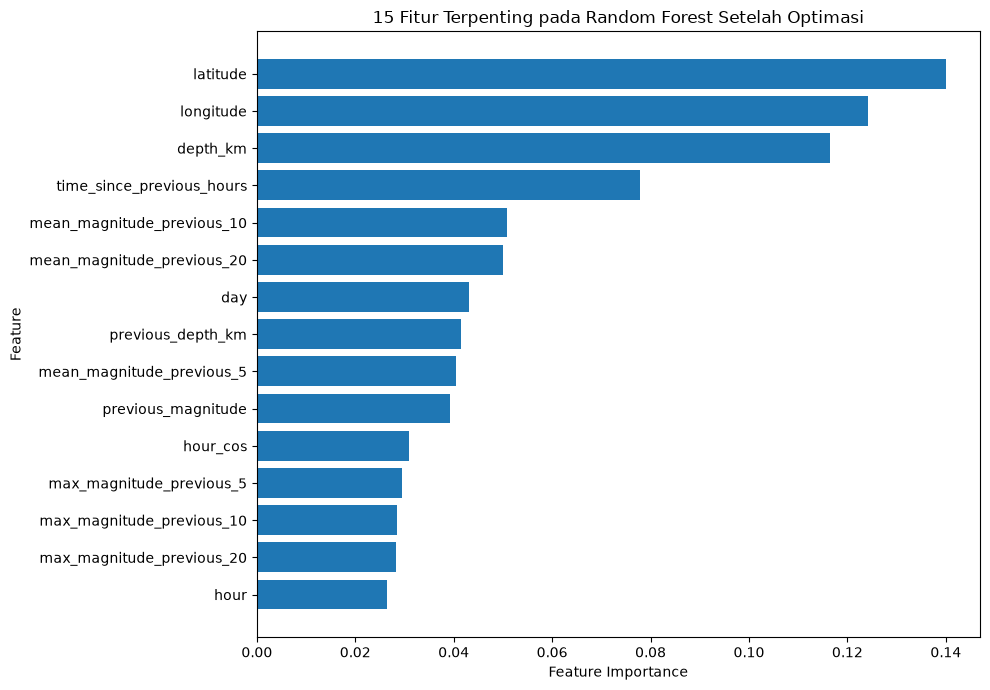

In [25]:
import matplotlib.pyplot as plt

top_features = feature_importance_tuned.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("15 Fitur Terpenting pada Random Forest Setelah Optimasi")
plt.tight_layout()
plt.show()